# Análisis ANOVA para Selección de Variables Categóricas
## ML Challenge: Predicción de Riesgo de Accidentes de Tráfico

Este notebook implementa un análisis estadístico riguroso usando ANOVA para evaluar la relevancia de variables categóricas sobre la variable objetivo `accident_risk`.

In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, tukey_hsd
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Cargar datos
train_df = pd.read_csv('../data/train.csv')
print(f"Dimensiones del dataset: {train_df.shape}")
print(f"Variables categóricas identificadas: {train_df.select_dtypes(include=['object']).columns.tolist()}")

Dimensiones del dataset: (517754, 14)
Variables categóricas identificadas: ['road_type', 'lighting', 'weather', 'time_of_day']


## 1. Análisis ANOVA de Una Vía

Evaluamos si las variables categóricas tienen un efecto estadísticamente significativo sobre el riesgo de accidentes.

In [3]:
def realizar_anova(data, var_categorica, var_objetivo):
    """
    Realiza ANOVA de una vía y calcula el tamaño del efecto.
    """
    # Preparar grupos
    grupos = []
    categorias = data[var_categorica].unique()
    
    for categoria in categorias:
        grupo_datos = data[data[var_categorica] == categoria][var_objetivo]
        grupos.append(grupo_datos)
    
    # ANOVA
    f_stat, p_value = f_oneway(*grupos)
    
    # Calcular eta-cuadrado (tamaño del efecto)
    media_general = data[var_objetivo].mean()
    ss_total = ((data[var_objetivo] - media_general) ** 2).sum()
    
    ss_between = 0
    for categoria in categorias:
        grupo_datos = data[data[var_categorica] == categoria][var_objetivo]
        media_grupo = grupo_datos.mean()
        n_grupo = len(grupo_datos)
        ss_between += n_grupo * (media_grupo - media_general) ** 2
    
    eta_cuadrado = ss_between / ss_total if ss_total > 0 else 0
    
    # Interpretación del tamaño del efecto
    if eta_cuadrado < 0.01:
        interpretacion = "Muy pequeño"
    elif eta_cuadrado < 0.06:
        interpretacion = "Pequeño"
    elif eta_cuadrado < 0.14:
        interpretacion = "Mediano"
    else:
        interpretacion = "Grande"
    
    return {
        'Variable': var_categorica,
        'F_Estadistico': f_stat,
        'Valor_P': p_value,
        'Eta_Cuadrado': eta_cuadrado,
        'Tamaño_Efecto': interpretacion,
        'Significativo': p_value < 0.05,
        'N_Categorias': len(categorias)
    }

In [4]:
# Variables categóricas a analizar
variables_categoricas = ['road_type', 'lighting', 'weather', 'time_of_day']
variable_objetivo = 'accident_risk'

# Realizar ANOVA para cada variable
resultados_anova = []
for var in variables_categoricas:
    resultado = realizar_anova(train_df, var, variable_objetivo)
    resultados_anova.append(resultado)
    print(f"Analizando {var}: F={resultado['F_Estadistico']:.2f}, p={resultado['Valor_P']:.4f}")

# Crear DataFrame con resultados
df_anova = pd.DataFrame(resultados_anova)
df_anova = df_anova.sort_values('Eta_Cuadrado', ascending=False)

print("\n" + "="*60)
print("RESULTADOS ANOVA")
print("="*60)
display(df_anova.style.format({
    'F_Estadistico': '{:.2f}',
    'Valor_P': '{:.4f}',
    'Eta_Cuadrado': '{:.4f}'
}).background_gradient(subset=['Eta_Cuadrado'], cmap='RdYlGn'))

Analizando road_type: F=119.42, p=0.0000
Analizando lighting: F=71752.06, p=0.0000
Analizando weather: F=10189.45, p=0.0000
Analizando time_of_day: F=26.39, p=0.0000

RESULTADOS ANOVA


,Variable,F_Estadistico,Valor_P,Eta_Cuadrado,Tamaño_Efecto,Significativo,N_Categorias
1,lighting,71752.06,0.0000,0.2170,Grande,True,3
2,weather,10189.45,0.0000,0.0379,Pequeño,True,3
0,road_type,119.42,0.0000,0.0005,Muy pequeño,True,3
3,time_of_day,26.39,0.0000,0.0001,Muy pequeño,True,3


## 2. Visualización de Resultados ANOVA

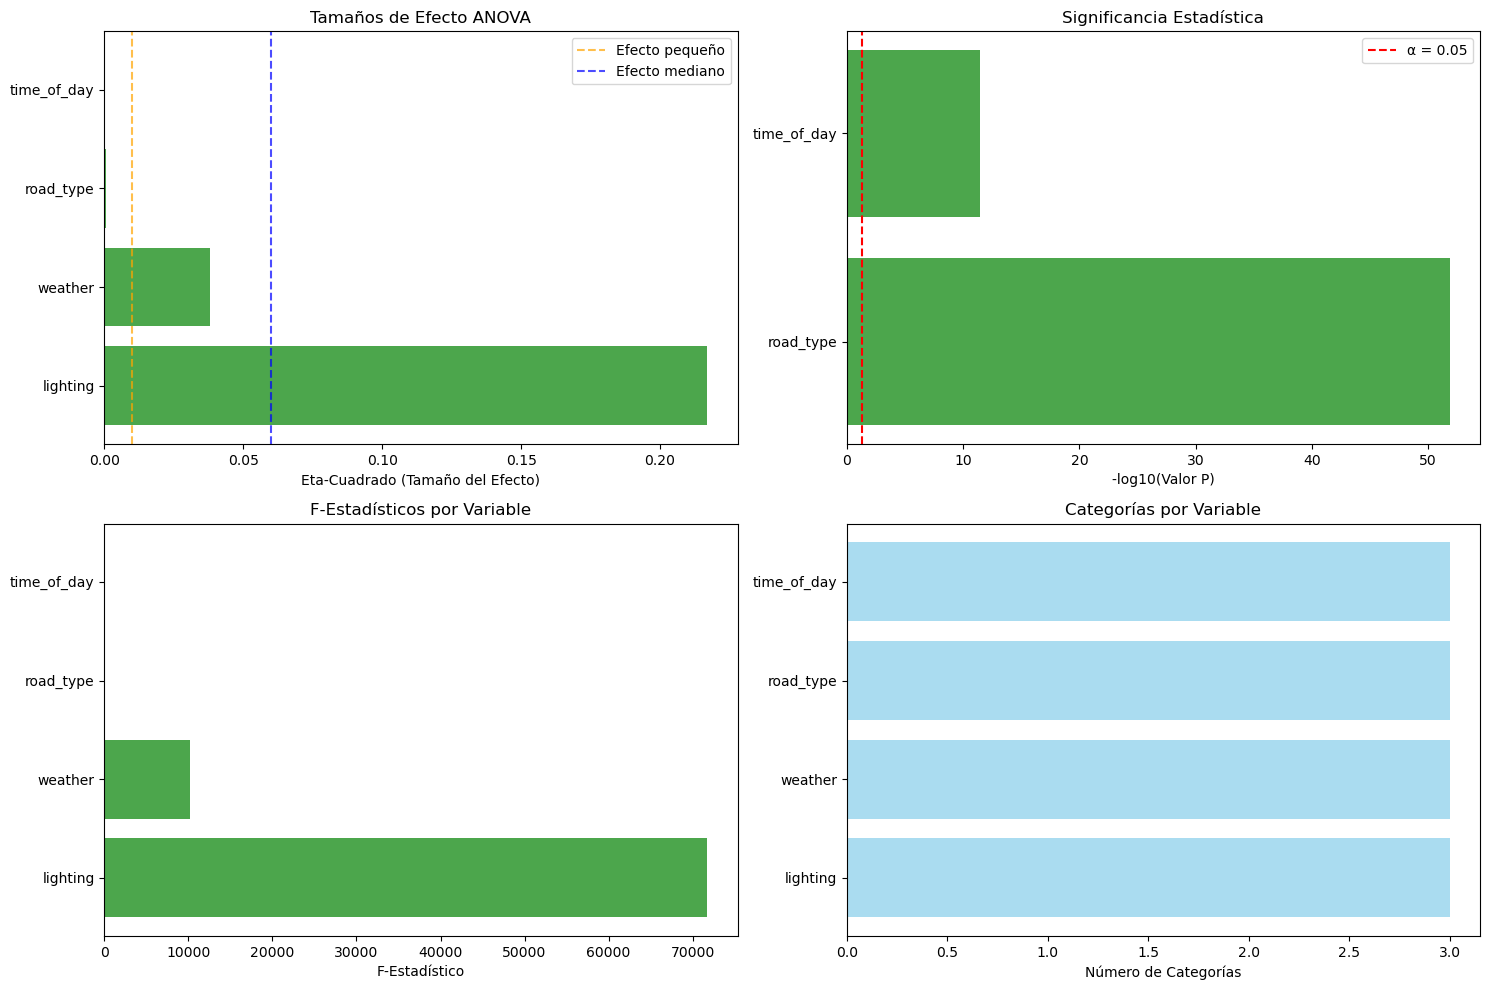

In [5]:
# Visualización de resultados ANOVA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tamaños de efecto
ax1 = axes[0, 0]
colores = ['red' if not sig else 'green' for sig in df_anova['Significativo']]
ax1.barh(df_anova['Variable'], df_anova['Eta_Cuadrado'], color=colores, alpha=0.7)
ax1.set_xlabel('Eta-Cuadrado (Tamaño del Efecto)')
ax1.set_title('Tamaños de Efecto ANOVA')
ax1.axvline(x=0.01, color='orange', linestyle='--', alpha=0.7, label='Efecto pequeño')
ax1.axvline(x=0.06, color='blue', linestyle='--', alpha=0.7, label='Efecto mediano')
ax1.legend()

# 2. Valores p (escala log)
ax2 = axes[0, 1]
log_p_values = -np.log10(df_anova['Valor_P'])
ax2.barh(df_anova['Variable'], log_p_values, color=colores, alpha=0.7)
ax2.set_xlabel('-log10(Valor P)')
ax2.set_title('Significancia Estadística')
ax2.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='α = 0.05')
ax2.legend()

# 3. F-estadísticos
ax3 = axes[1, 0]
ax3.barh(df_anova['Variable'], df_anova['F_Estadistico'], color=colores, alpha=0.7)
ax3.set_xlabel('F-Estadístico')
ax3.set_title('F-Estadísticos por Variable')

# 4. Número de categorías
ax4 = axes[1, 1]
ax4.barh(df_anova['Variable'], df_anova['N_Categorias'], color='skyblue', alpha=0.7)
ax4.set_xlabel('Número de Categorías')
ax4.set_title('Categorías por Variable')

plt.tight_layout()
plt.show()

## 3. Análisis Detallado por Variable

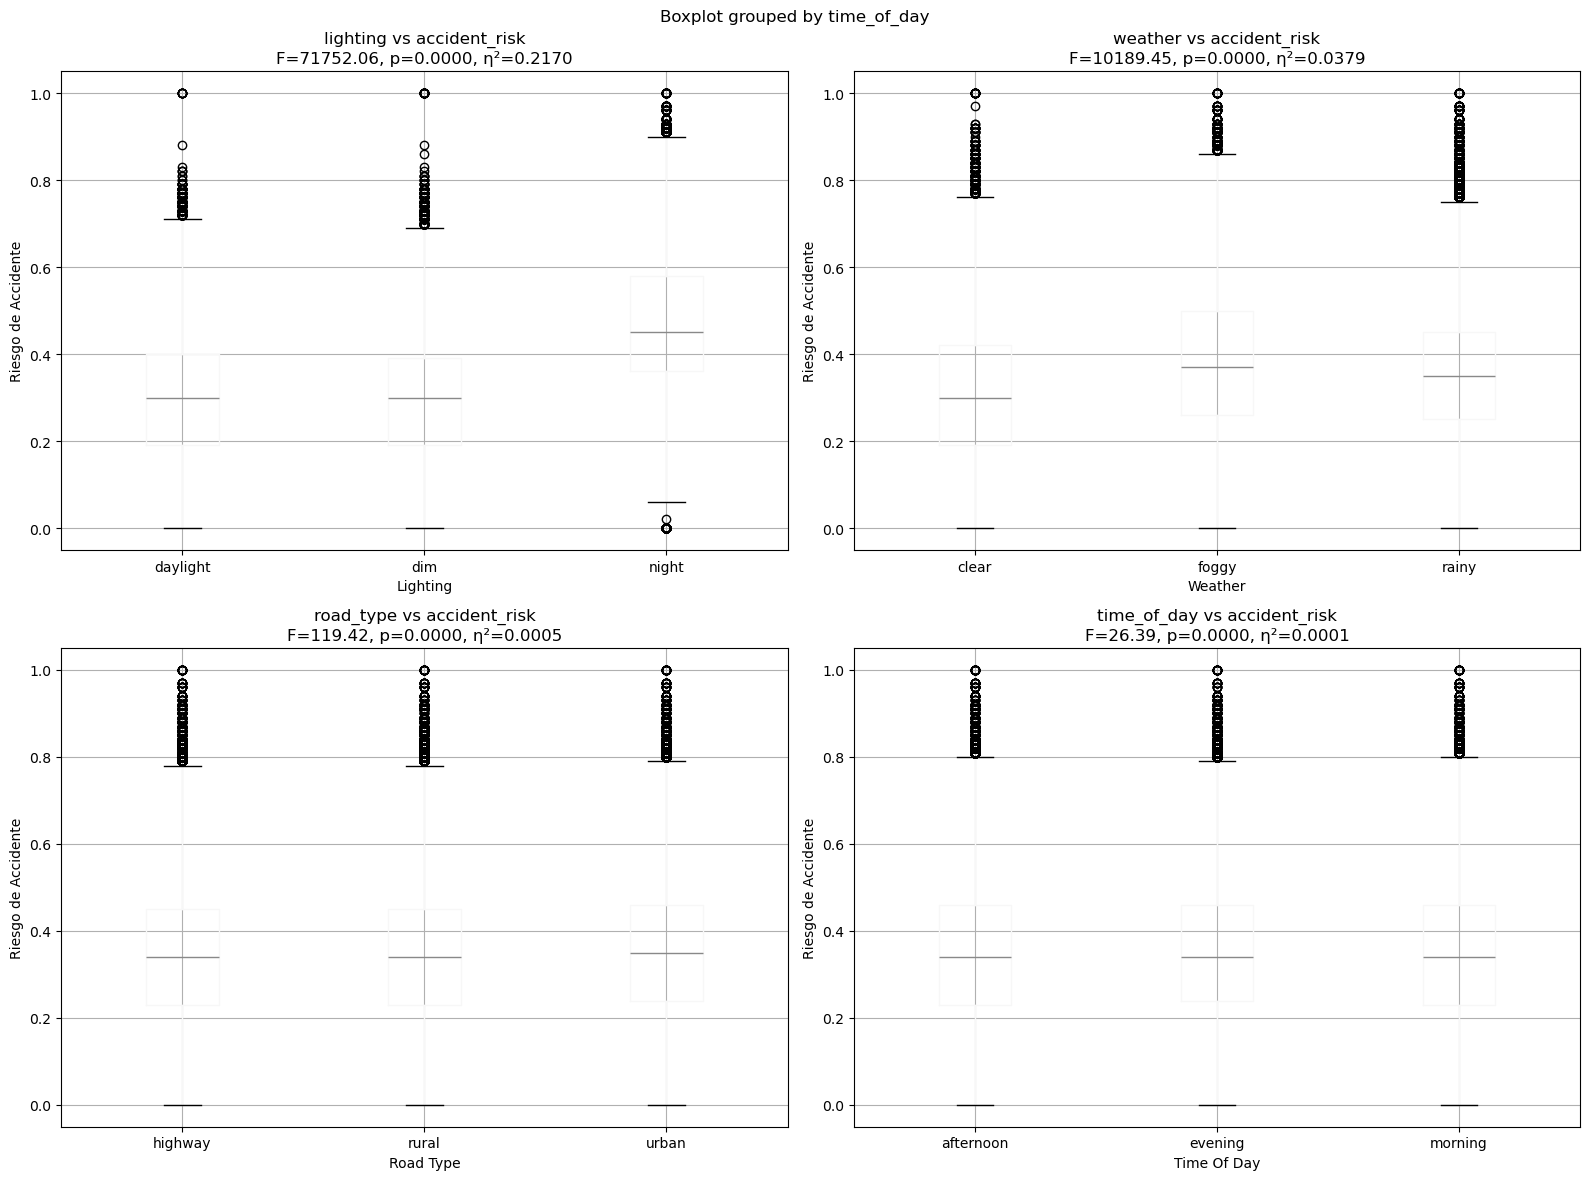

In [6]:
# Boxplots para variables significativas
variables_significativas = df_anova[df_anova['Significativo']]['Variable'].tolist()

if variables_significativas:
    n_vars = len(variables_significativas)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, var in enumerate(variables_significativas[:4]):
        if i < len(axes):
            ax = axes[i]
            train_df.boxplot(column=variable_objetivo, by=var, ax=ax)
            
            # Obtener estadísticos para el título
            resultado = df_anova[df_anova['Variable'] == var].iloc[0]
            ax.set_title(f'{var} vs {variable_objetivo}\n'
                        f'F={resultado["F_Estadistico"]:.2f}, '
                        f'p={resultado["Valor_P"]:.4f}, '
                        f'η²={resultado["Eta_Cuadrado"]:.4f}')
            ax.set_xlabel(var.replace('_', ' ').title())
            ax.set_ylabel('Riesgo de Accidente')
    
    # Ocultar subplots no utilizados
    for i in range(len(variables_significativas), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 4. Análisis Post-Hoc (Tukey HSD)

In [7]:
# Análisis post-hoc para variables con más de 2 categorías
print("ANÁLISIS POST-HOC (Tukey HSD)")
print("="*50)

for var in variables_significativas:
    n_categorias = df_anova[df_anova['Variable'] == var]['N_Categorias'].iloc[0]
    
    if n_categorias > 2:
        print(f"\nAnálisis post-hoc para {var}:")
        
        # Preparar datos para Tukey HSD
        grupos = []
        nombres_grupos = []
        for categoria in train_df[var].unique():
            grupo_datos = train_df[train_df[var] == categoria][variable_objetivo]
            grupos.append(grupo_datos)
            nombres_grupos.append(categoria)
        
        try:
            resultado_tukey = tukey_hsd(*grupos)
            
            print("  Comparaciones por pares (valores p):")
            for i in range(len(nombres_grupos)):
                for j in range(i+1, len(nombres_grupos)):
                    p_val = resultado_tukey.pvalue[i, j]
                    significativo = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
                    print(f"    {nombres_grupos[i]} vs {nombres_grupos[j]}: p={p_val:.4f} {significativo}")
        except Exception as e:
            print(f"  No se pudo realizar Tukey HSD: {e}")

ANÁLISIS POST-HOC (Tukey HSD)

Análisis post-hoc para lighting:
  Comparaciones por pares (valores p):
    daylight vs dim: p=0.0000 ***
    daylight vs night: p=0.0000 ***
    dim vs night: p=0.0000 ***

Análisis post-hoc para weather:
  Comparaciones por pares (valores p):
    rainy vs clear: p=0.0000 ***
    rainy vs foggy: p=0.0000 ***
    clear vs foggy: p=0.0000 ***

Análisis post-hoc para road_type:
  Comparaciones por pares (valores p):
    urban vs rural: p=0.0000 ***
    urban vs highway: p=0.0000 ***
    rural vs highway: p=0.8877 

Análisis post-hoc para time_of_day:
  Comparaciones por pares (valores p):
    afternoon vs evening: p=0.0000 ***
    afternoon vs morning: p=0.6937 
    evening vs morning: p=0.0000 ***


## 5. Análisis de Variables Booleanas (Pruebas t)

In [8]:
# Análisis de variables booleanas
variables_booleanas = ['road_signs_present', 'public_road', 'holiday', 'school_season']
resultados_ttest = []

print("ANÁLISIS DE VARIABLES BOOLEANAS (Pruebas t)")
print("="*50)

for var in variables_booleanas:
    # Separar grupos
    grupo_true = train_df[train_df[var] == True][variable_objetivo]
    grupo_false = train_df[train_df[var] == False][variable_objetivo]
    
    # Prueba t independiente
    t_stat, p_value = stats.ttest_ind(grupo_true, grupo_false)
    
    # Calcular d de Cohen (tamaño del efecto)
    std_pooled = np.sqrt(((len(grupo_true) - 1) * grupo_true.var() + 
                         (len(grupo_false) - 1) * grupo_false.var()) / 
                        (len(grupo_true) + len(grupo_false) - 2))
    cohens_d = (grupo_true.mean() - grupo_false.mean()) / std_pooled
    
    # Interpretación del tamaño del efecto
    if abs(cohens_d) < 0.2:
        interpretacion_efecto = "Muy pequeño"
    elif abs(cohens_d) < 0.5:
        interpretacion_efecto = "Pequeño"
    elif abs(cohens_d) < 0.8:
        interpretacion_efecto = "Mediano"
    else:
        interpretacion_efecto = "Grande"
    
    resultados_ttest.append({
        'Variable': var,
        'T_Estadistico': t_stat,
        'Valor_P': p_value,
        'D_Cohen': cohens_d,
        'Tamaño_Efecto': interpretacion_efecto,
        'Significativo': p_value < 0.05,
        'Media_True': grupo_true.mean(),
        'Media_False': grupo_false.mean()
    })

df_ttest = pd.DataFrame(resultados_ttest)
df_ttest = df_ttest.sort_values('Valor_P')

display(df_ttest.style.format({
    'T_Estadistico': '{:.3f}',
    'Valor_P': '{:.4f}',
    'D_Cohen': '{:.3f}',
    'Media_True': '{:.4f}',
    'Media_False': '{:.4f}'
}).background_gradient(subset=['Valor_P'], cmap='RdYlGn_r'))

ANÁLISIS DE VARIABLES BOOLEANAS (Pruebas t)


,Variable,T_Estadistico,Valor_P,D_Cohen,Tamaño_Efecto,Significativo,Media_True,Media_False
2,holiday,36.838,0.0000,0.102,Muy pequeño,True,0.3608,0.3438
1,public_road,22.340,0.0000,0.062,Muy pequeño,True,0.3575,0.3472
3,school_season,-0.703,0.4821,-0.002,Muy pequeño,False,0.3522,0.3525
0,road_signs_present,0.453,0.6506,0.001,Muy pequeño,False,0.3525,0.3523


## 6. Recomendaciones para Selección de Variables

In [9]:
def generar_recomendaciones(df_anova, df_ttest, min_efecto=0.01):
    """
    Genera recomendaciones para selección de variables basadas en análisis estadístico.
    """
    recomendaciones = {
        'mantener': [],
        'eliminar': [],
        'agrupar_categorias': [],
        'investigar': []
    }
    
    # Analizar variables categóricas
    for _, row in df_anova.iterrows():
        var_name = row['Variable']
        
        if not row['Significativo']:
            if row['Eta_Cuadrado'] < min_efecto:
                recomendaciones['eliminar'].append({
                    'variable': var_name,
                    'razon': f'No significativa (p={row["Valor_P"]:.4f}) y efecto muy pequeño'
                })
            else:
                recomendaciones['investigar'].append({
                    'variable': var_name,
                    'razon': 'No significativa pero efecto moderado - revisar confusión'
                })
        else:
            if row['Eta_Cuadrado'] >= 0.06:  # Efecto mediano a grande
                recomendaciones['mantener'].append({
                    'variable': var_name,
                    'razon': f'Significativa con efecto {row["Tamaño_Efecto"].lower()}'
                })
            elif row['N_Categorias'] > 4:
                recomendaciones['agrupar_categorias'].append({
                    'variable': var_name,
                    'razon': f'Significativa pero muchas categorías ({row["N_Categorias"]}) - considerar agrupación'
                })
            else:
                recomendaciones['mantener'].append({
                    'variable': var_name,
                    'razon': 'Significativa con efecto pequeño pero significativo'
                })
    
    # Analizar variables booleanas
    for _, row in df_ttest.iterrows():
        var_name = row['Variable']
        
        if row['Significativo'] and abs(row['D_Cohen']) > 0.1:
            recomendaciones['mantener'].append({
                'variable': var_name,
                'razon': f'Significativa con efecto {row["Tamaño_Efecto"].lower()} (d={row["D_Cohen"]:.3f})'
            })
        elif not row['Significativo'] or abs(row['D_Cohen']) <= 0.1:
            recomendaciones['eliminar'].append({
                'variable': var_name,
                'razon': f'No significativa o efecto muy pequeño (p={row["Valor_P"]:.4f})'
            })
    
    return recomendaciones

# Generar recomendaciones
recomendaciones = generar_recomendaciones(df_anova, df_ttest)

print("RECOMENDACIONES PARA SELECCIÓN DE VARIABLES")
print("="*60)

for accion, variables in recomendaciones.items():
    if variables:
        print(f"\n{accion.upper().replace('_', ' ')}:")
        for var_info in variables:
            print(f"  • {var_info['variable']}: {var_info['razon']}")

RECOMENDACIONES PARA SELECCIÓN DE VARIABLES

MANTENER:
  • lighting: Significativa con efecto grande
  • weather: Significativa con efecto pequeño pero significativo
  • road_type: Significativa con efecto pequeño pero significativo
  • time_of_day: Significativa con efecto pequeño pero significativo
  • holiday: Significativa con efecto muy pequeño (d=0.102)

ELIMINAR:
  • public_road: No significativa o efecto muy pequeño (p=0.0000)
  • school_season: No significativa o efecto muy pequeño (p=0.4821)
  • road_signs_present: No significativa o efecto muy pequeño (p=0.6506)


## 7. Sugerencias de Agrupación de Categorías

In [10]:
def sugerir_agrupacion_categorias(data, var_categorica, var_objetivo, max_grupos=3):
    """
    Sugiere cómo agrupar categorías basándose en medias de la variable objetivo.
    """
    # Calcular media de la variable objetivo para cada categoría
    medias_categorias = data.groupby(var_categorica)[var_objetivo].agg(['mean', 'count']).reset_index()
    medias_categorias = medias_categorias.sort_values('mean')
    
    # Agrupación simple por cuantiles de medias
    medias_categorias['grupo'] = pd.qcut(medias_categorias['mean'], 
                                        q=min(max_grupos, len(medias_categorias)), 
                                        labels=['Riesgo_Bajo', 'Riesgo_Medio', 'Riesgo_Alto'][:min(max_grupos, len(medias_categorias))],
                                        duplicates='drop')
    
    diccionario_agrupacion = {}
    for grupo_id in medias_categorias['grupo'].unique():
        categorias_grupo = medias_categorias[medias_categorias['grupo'] == grupo_id][var_categorica].tolist()
        media_grupo = medias_categorias[medias_categorias['grupo'] == grupo_id]['mean'].mean()
        diccionario_agrupacion[grupo_id] = {
            'categorias': categorias_grupo,
            'media_riesgo': media_grupo,
            'total_observaciones': medias_categorias[medias_categorias['grupo'] == grupo_id]['count'].sum()
        }
    
    return diccionario_agrupacion

# Sugerencias de agrupación para variables que lo necesiten
print("SUGERENCIAS DE AGRUPACIÓN DE CATEGORÍAS")
print("="*50)

for var in recomendaciones.get('agrupar_categorias', []):
    var_name = var['variable']
    print(f"\nSugerencias de agrupación para {var_name}:")
    agrupacion = sugerir_agrupacion_categorias(train_df, var_name, variable_objetivo)
    
    for nombre_grupo, info_grupo in agrupacion.items():
        print(f"  {nombre_grupo}:")
        print(f"    Categorías: {info_grupo['categorias']}")
        print(f"    Riesgo medio: {info_grupo['media_riesgo']:.4f}")
        print(f"    Observaciones: {info_grupo['total_observaciones']}")

SUGERENCIAS DE AGRUPACIÓN DE CATEGORÍAS


## 8. Resumen Final y Variables Seleccionadas

In [11]:
# Crear lista final de variables recomendadas
variables_mantener = [var['variable'] for var in recomendaciones['mantener']]
variables_numericas = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

print("RESUMEN DEL ANÁLISIS ESTADÍSTICO")
print("="*50)

print(f"\nVariables Categóricas Analizadas: {len(variables_categoricas)}")
print(f"Variables Booleanas Analizadas: {len(variables_booleanas)}")
print(f"Variables Estadísticamente Significativas: {len(variables_mantener)}")

print(f"\nVARIABLES RECOMENDADAS PARA EL MODELO:")
print(f"  • Categóricas/Booleanas: {variables_mantener}")
print(f"  • Numéricas: {variables_numericas}")
print(f"  • Total de variables: {len(variables_mantener) + len(variables_numericas)}")

# Guardar resultados para uso posterior
resultados_seleccion = {
    'variables_significativas': variables_mantener,
    'variables_numericas': variables_numericas,
    'resultados_anova': df_anova,
    'resultados_ttest': df_ttest,
    'recomendaciones': recomendaciones
}

print("\n✓ Análisis ANOVA completado. Resultados guardados para la fase de preprocesamiento.")

RESUMEN DEL ANÁLISIS ESTADÍSTICO

Variables Categóricas Analizadas: 4
Variables Booleanas Analizadas: 4
Variables Estadísticamente Significativas: 5

VARIABLES RECOMENDADAS PARA EL MODELO:
  • Categóricas/Booleanas: ['lighting', 'weather', 'road_type', 'time_of_day', 'holiday']
  • Numéricas: ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
  • Total de variables: 9

✓ Análisis ANOVA completado. Resultados guardados para la fase de preprocesamiento.


## Conclusiones

Este análisis ANOVA proporciona una base estadística sólida para la selección de variables:

1. **Variables Significativas**: Identificadas mediante pruebas estadísticas rigurosas
2. **Tamaño del Efecto**: Evaluado usando eta-cuadrado y d de Cohen
3. **Agrupación de Categorías**: Sugerencias para variables con muchas categorías
4. **Justificación Estadística**: Decisiones basadas en evidencia, no intuición

Los resultados de este análisis deben utilizarse en la fase de preprocesamiento para crear un modelo más robusto y estadísticamente fundamentado.